<ipython-input-1-74d5d76158bf>:7: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263

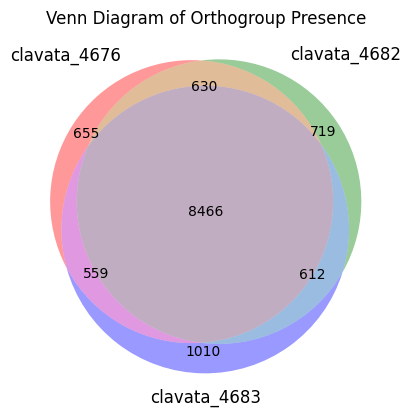

In [ ]:
# Constructs a venn-diagram for comparing the Orthogroups present in 3
# Clavata protein assemblies for the unfiltered orthogroups.

import pandas as pd
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Load the TSV file into a DataFrame
file_path = "/content/drive/MyDrive/Orthogroups.tsv"
data = pd.read_csv(file_path, sep='\t')

# Select the three columns for the Venn diagram
col1 = "4676-W1_S5_longest_ORFs_aa"
col2 = "4682-W1_S8_longest_ORFs_aa"
col3 = "4683-W1_S9_longest_ORFs_aa"

# Determine presence/absence for each column (assuming non-empty = presence)
set1 = set(data[data[col1].notnull()].index)
set2 = set(data[data[col2].notnull()].index)
set3 = set(data[data[col3].notnull()].index)

# Create the Venn diagram
venn = venn3([set1, set2, set3], ('clavata_4676', 'clavata_4682', 'clavata_4683'))

# Add labels and title
plt.title("Venn Diagram of Orthogroup Presence")
plt.show()


In [ ]:
# Extract shared orthogroups
shared_orthogroups = set1 & set2 & set3  # Intersection of sets

# Initialize counters
matching_orthogroups = 0
total_shared = len(shared_orthogroups)

# Compare gene IDs for each shared orthogroup
for og in shared_orthogroups:
    genes_col1 = data.at[og, col1]
    genes_col2 = data.at[og, col2]
    genes_col3 = data.at[og, col3]

    # Check if all sets of genes are identical
    if genes_col1 == genes_col2 == genes_col3:
        matching_orthogroups += 1

# Print results
print(f"Total shared orthogroups: {total_shared}")
print(f"Shared orthogroups with identical genes: {matching_orthogroups}")



Total shared orthogroups: 8466
Shared orthogroups with identical genes: 0


In [ ]:
# Identify shared orthogroups
shared_orthogroups = set1 & set2 & set3  # Intersection of orthogroups

# Initialize counters
matching_lengths = 0
total_shared = len(shared_orthogroups)

# Compare lengths for each shared orthogroup
for og in shared_orthogroups:
    # Extract gene lists from each column
    genes_col1 = str(data.at[og, col1]).split(",") if pd.notnull(data.at[og, col1]) else []
    genes_col2 = str(data.at[og, col2]).split(",") if pd.notnull(data.at[og, col2]) else []
    genes_col3 = str(data.at[og, col3]).split(",") if pd.notnull(data.at[og, col3]) else []

    # Compare lengths
    if len(genes_col1) == len(genes_col2) == len(genes_col3):
        matching_lengths += 1

# Print results
print(f"Total shared orthogroups: {total_shared}")
print(f"Shared orthogroups with matching lengths: {matching_lengths}")


Total shared orthogroups: 8466
Shared orthogroups with matching lengths: 3434


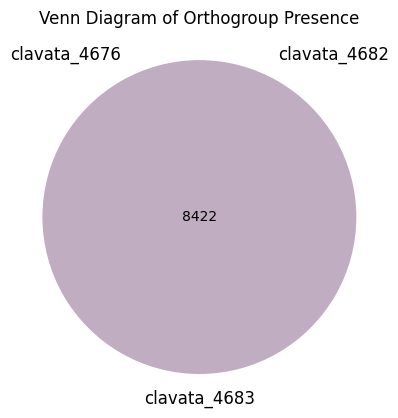

In [ ]:
# Code to create a venn diagram comparing the orthogroups present
# in 3 Clavata protein assemblies, this time with filtered orthogroups.

import pandas as pd
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Load the TSV file into a DataFrame
file_path = "/content/drive/MyDrive/Filtered_orthofinder.tsv"
data = pd.read_csv(file_path, sep='\t')

# Select the three columns for the Venn diagram
col1 = "4676-W1_S5_longest_ORFs_aa"
col2 = "4682-W1_S8_longest_ORFs_aa"
col3 = "4683-W1_S9_longest_ORFs_aa"

# Determine presence/absence for each column (assuming non-empty = presence)
set1 = set(data[data[col1].notnull()].index)
set2 = set(data[data[col2].notnull()].index)
set3 = set(data[data[col3].notnull()].index)

# Create the Venn diagram
venn = venn3([set1, set2, set3], ('clavata_4676', 'clavata_4682', 'clavata_4683'))

# Add labels and title
plt.title("Venn Diagram of Orthogroup Presence")
plt.show()
